# Encoding

encoding means transforming object or categorical data into numerical

In [2]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns 
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv(r"C:\Users\Ruhan\Desktop\QWETRUM task1- Syed MAhad Ur Rayyan\Messy_Employee_dataset.csv")
df.head()

,Employee_ID,First_Name,Last_Name,Age,Department_Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work
0,EMP1000,Bob,Davis,25.0,DevOps-California,Active,4/2/2021,59767.65,bob.davis@example.com,-1651623197,Average,True
1,EMP1001,Bob,Brown,NaN,Finance-Texas,Active,7/10/2020,65304.66,bob.brown@example.com,-1898471390,Excellent,True
2,EMP1002,Alice,Jones,NaN,Admin-Nevada,Pending,12/7/2023,88145.90,alice.jones@example.com,-5596363211,Good,True
3,EMP1003,Eva,Davis,25.0,Admin-Nevada,Inactive,11/27/2021,69450.99,eva.davis@example.com,-3476490784,Good,True
4,EMP1004,Frank,Williams,25.0,Cloud Tech-Florida,Active,1/5/2022,109324.61,frank.williams@example.com,-1586734256,Poor,False


OnehotEncoding
it requires 2d array
it return sub column with sparse matrix from column


In [17]:
pd.get_dummies(df["Remote_Work"])

,False,True
0,0,1
1,0,1
2,0,1
3,0,1
4,1,0
...,...,...
1015,0,1
1016,0,1
1017,1,0
1018,0,1


In [21]:
#drop fisrt means remove fisrt column because it is obv if true has 0 than it is false no need of 2 columns
ohe = OneHotEncoder(drop="first")
ar = ohe.fit_transform(df[["Remote_Work"]]).toarray()
ar

array([[1.],
       [1.],
       [1.],
       ...,
       [0.],
       [1.],
       [0.]])

 Sparse Row is a matrix which is mostly filled with o and 1

In [22]:
df1=pd.DataFrame(ar,columns=["True"])
df1.head()

,True
0,1.0
1,1.0
2,1.0
3,1.0
4,0.0


LabelEncoding
use 1d array 
use for nominal data 
assign numbers to nominal data


In [23]:
from sklearn.preprocessing import LabelEncoder


In [24]:
le=LabelEncoder()
le.fit(df["Performance_Score"])

LabelEncoder()

In [29]:
df["Performance_Score"]=le.transform(df["Performance_Score"])

In [30]:
df["Performance_Score"].unique()

array([0, 1, 2, 3])

In [31]:
df.head()

,Employee_ID,First_Name,Last_Name,Age,Department_Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work
0,EMP1000,Bob,Davis,25.0,DevOps-California,Active,4/2/2021,59767.65,bob.davis@example.com,-1651623197,0,True
1,EMP1001,Bob,Brown,NaN,Finance-Texas,Active,7/10/2020,65304.66,bob.brown@example.com,-1898471390,1,True
2,EMP1002,Alice,Jones,NaN,Admin-Nevada,Pending,12/7/2023,88145.90,alice.jones@example.com,-5596363211,2,True
3,EMP1003,Eva,Davis,25.0,Admin-Nevada,Inactive,11/27/2021,69450.99,eva.davis@example.com,-3476490784,2,True
4,EMP1004,Frank,Williams,25.0,Cloud Tech-Florida,Active,1/5/2022,109324.61,frank.williams@example.com,-1586734256,3,False


Ordinal Encoding 
use 2d array
use for ordinal data 
give sequential number to ordinal data 


In [33]:
from sklearn.preprocessing import OrdinalEncoder

In [34]:
df["Status"].unique()

array(['Active', 'Pending', 'Inactive'], dtype=object)

In [36]:
data=[['Active', 'Pending', 'Inactive']]
oe=OrdinalEncoder(categories=data)
df["Status"]=oe.fit_transform(df[["Status"]])


In [37]:
df.head()

,Employee_ID,First_Name,Last_Name,Age,Department_Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work
0,EMP1000,Bob,Davis,25.0,DevOps-California,0.0,4/2/2021,59767.65,bob.davis@example.com,-1651623197,0,True
1,EMP1001,Bob,Brown,NaN,Finance-Texas,0.0,7/10/2020,65304.66,bob.brown@example.com,-1898471390,1,True
2,EMP1002,Alice,Jones,NaN,Admin-Nevada,1.0,12/7/2023,88145.90,alice.jones@example.com,-5596363211,2,True
3,EMP1003,Eva,Davis,25.0,Admin-Nevada,2.0,11/27/2021,69450.99,eva.davis@example.com,-3476490784,2,True
4,EMP1004,Frank,Williams,25.0,Cloud Tech-Florida,0.0,1/5/2022,109324.61,frank.williams@example.com,-1586734256,3,False


# Outliers


removing outlier through Iqr

In [8]:
df["Age"].fillna(df["Age"].mode()[0],inplace=True)

In [7]:
df["Salary"].fillna(df["Salary"].mode()[0],inplace=True)

,Employee_ID,First_Name,Last_Name,Age,Department_Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work
0,EMP1000,Bob,Davis,25.000000,DevOps-California,0.0,4/2/2021,59767.65,bob.davis@example.com,-1651623197,0,True
1,EMP1001,Bob,Brown,32.484549,Finance-Texas,0.0,7/10/2020,65304.66,bob.brown@example.com,-1898471390,1,True
2,EMP1002,Alice,Jones,32.484549,Admin-Nevada,1.0,12/7/2023,88145.90,alice.jones@example.com,-5596363211,2,True
3,EMP1003,Eva,Davis,25.000000,Admin-Nevada,2.0,11/27/2021,69450.99,eva.davis@example.com,-3476490784,2,True
4,EMP1004,Frank,Williams,25.000000,Cloud Tech-Florida,0.0,1/5/2022,109324.61,frank.williams@example.com,-1586734256,3,False


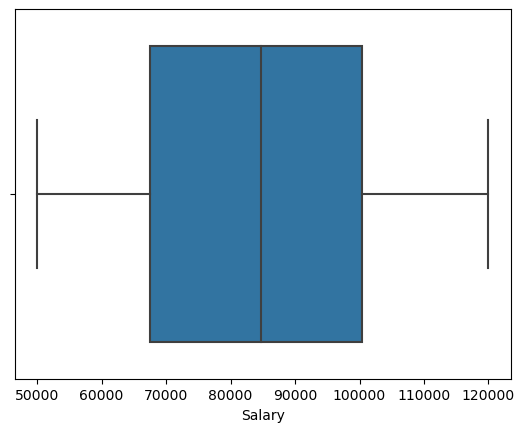

In [11]:
sns.boxplot(x="Salary",data=df)
plt.show()

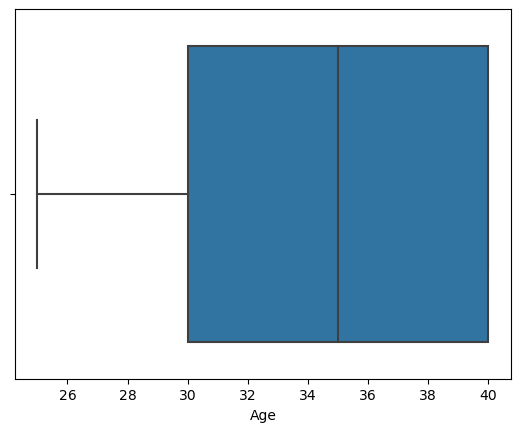

In [10]:
sns.boxplot(x="Age",data=df)
plt.show()

In [22]:
df.shape

(1020, 12)

In [14]:
q1=df["Age"].quantile(0.25)
q3=df["Age"].quantile(0.75)
q1,q3

(30.0, 40.0)

In [15]:
Iqr=q3-q1

In [17]:
max_range=q3 + (1.5*Iqr)
min_range=q1 - (1.5*Iqr)
max_range,min_range

(55.0, 15.0)

In [21]:
new_df=df[df["Age"]<=max_range]
new_df.shape

(1020, 12)

In [23]:
sq1=df["Salary"].quantile(0.25)
sq3=df["Salary"].quantile(0.75)
sq1,sq3

(67498.3475, 100372.6625)

In [24]:
sIqr=sq3-sq1

In [25]:
smax_range=sq3 + (1.5*sIqr)
smin_range=sq1 - (1.5*sIqr)
smax_range,smin_range

(149684.135, 18186.875)

In [27]:
df.describe()

,Age,Salary,Phone
count,1020.000000,1020.000000,1.020000e+03
mean,34.039216,84374.725186,-4.942253e+09
std,5.886432,20272.086516,2.817326e+09
min,25.000000,50047.320000,-9.994973e+09
25%,30.000000,67498.347500,-7.341992e+09
50%,35.000000,84711.750000,-4.943997e+09
75%,40.000000,100372.662500,-2.520391e+09
max,40.000000,119971.650000,-3.896086e+06


In [33]:
new_df = df[(df["Salary"] <= smax_range) & (df["Salary"] >= smin_range)]

new_df.shape

(1020, 12)

removing outlier through z score 

if data is normally distributed then all the data lies between u-3std - u+3std or -3<zscore<+3

1) direct method 

In [35]:
min_range=df["Salary"].mean()-(3*df["Salary"].std())
max_range=df["Salary"].mean()+(3*df["Salary"].std())
max_range,min_range

(145190.98473329574, 23558.465639253256)

In [36]:
new_df = df[(df["Salary"] <= smax_range) & (df["Salary"] >= smin_range)]

new_df.shape

(1020, 12)

2. zscore 

In [40]:
df["Z_score"]=(df["Salary"]-df["Salary"].mean())/df["Salary"].std()
df.head()

,Employee_ID,First_Name,Last_Name,Age,Department_Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work,Z_score
0,EMP1000,Bob,Davis,25.0,DevOps-California,Active,4/2/2021,59767.65,bob.davis@example.com,-1651623197,Average,True,-1.213840
1,EMP1001,Bob,Brown,40.0,Finance-Texas,Active,7/10/2020,65304.66,bob.brown@example.com,-1898471390,Excellent,True,-0.940706
2,EMP1002,Alice,Jones,40.0,Admin-Nevada,Pending,12/7/2023,88145.90,alice.jones@example.com,-5596363211,Good,True,0.186028
3,EMP1003,Eva,Davis,25.0,Admin-Nevada,Inactive,11/27/2021,69450.99,eva.davis@example.com,-3476490784,Good,True,-0.736172
4,EMP1004,Frank,Williams,25.0,Cloud Tech-Florida,Active,1/5/2022,109324.61,frank.williams@example.com,-1586734256,Poor,False,1.230751


In [41]:
new_df = df[(df["Z_score"] <=3) & (df["Z_score"] >=-3)]

new_df.shape

(1020, 13)